In [1]:
# ==========================================
# CELL 1 & 2: DDR-PINN ARCHITECTURE INIT
# ==========================================
import torch
import torch.nn as nn
import deepwave

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

# 1. Physical Grid Parameters (Matches Phase 1)
nx, ny = 70, 70
dx = 10.0
dt = 0.004
nt = 1000
num_shots = 5

# 2. Generate the "True" Target Data (25Hz)
# We create a simple true velocity model (a 1500m/s background with a 2500m/s anomaly)
v_true = torch.full((nx, ny), 1500.0, device=device)
v_true[30:50, 20:50] = 2500.0 # Rectangular anomaly

# 3. Setup the 5-Shot 25Hz Geometry
source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = 0
source_locations[:, 0, 1] = torch.round(torch.linspace(10, nx - 10, num_shots)).long().to(device)

receiver_locations = torch.zeros(num_shots, nx, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = 0
receiver_locations[:, :, 1] = torch.arange(nx, dtype=torch.long).repeat(num_shots, 1).to(device)

freq = 25.0
source_amplitudes = (
    deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq)
    .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
)

# Generate True Observed Data
with torch.no_grad():
    out_true = deepwave.scalar(
        v_true, grid_spacing=dx, dt=dt,
        source_amplitudes=source_amplitudes,
        source_locations=source_locations,
        receiver_locations=receiver_locations
    )
    observed_seismograms = out_true[-1].clone().detach()

print("True High-Frequency Multi-Shot Data Generated.")

# 4. The DDR-PINN Generator Network
class VelocityNet(nn.Module):
    def __init__(self):
        super(VelocityNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x, z):
        coords = torch.cat([x, z], dim=1)
        # Scale output to reasonable velocity ranges
        return 1500.0 + 3000.0 * torch.sigmoid(self.net(coords))

v_net = VelocityNet().to(device)
optimizer = torch.optim.Adam(v_net.parameters(), lr=1e-3)

# Create the spatial coordinate grid once
x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                torch.arange(ny, dtype=torch.float32), indexing='ij')
x_flat = x_grid.reshape(-1, 1).to(device)
z_flat = z_grid.reshape(-1, 1).to(device)

print("Neural Network Initialized and Bound to Spatial Grid.")

HPC Node Active: cuda



C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:564: UserWarning: pml_freq was not set, so defaulting to 25.0.
  warnings.warn(


True High-Frequency Multi-Shot Data Generated.
Neural Network Initialized and Bound to Spatial Grid.


In [2]:
# ==========================================
# CELL 3 & 4: DDR-PINN HYBRID OPTIMIZATION LOOP
# ==========================================

epochs = 150 # Running 150 epochs for the stress test
history = {'epoch': [], 'loss': []}

print(f"Igniting DDR-PINN Inversion for {epochs} epochs...")

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. The Generator Phase
    # The neural network predicts the velocity for every point on the grid
    v_pred_flat = v_net(x_flat, z_flat)
    v_pred = v_pred_flat.reshape(nx, ny)
    
    # 2. The Physics Engine Phase
    # Deepwave calculates the wavefield through the predicted velocity model
    out = deepwave.scalar(
        v_pred, grid_spacing=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_locations=source_locations,
        receiver_locations=receiver_locations
    )
    
    # 3. The Objective Function (Data Mismatch)
    synthetic_seismograms = out[-1]
    loss = torch.nn.functional.mse_loss(synthetic_seismograms, observed_seismograms)
    
    # 4. Backpropagation
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        history['epoch'].append(epoch)
        history['loss'].append(loss.item())
        print(f"Epoch {epoch:04d} | MSE Loss: {loss.item():.6f}")

print("\nDDR-PINN Optimization Complete.")

Igniting DDR-PINN Inversion for 150 epochs...


C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:564: UserWarning: pml_freq was not set, so defaulting to 25.0.
  warnings.warn(


Epoch 0000 | MSE Loss: 0.344502
Epoch 0010 | MSE Loss: 0.190607
Epoch 0020 | MSE Loss: 0.063181
Epoch 0030 | MSE Loss: 0.014146
Epoch 0040 | MSE Loss: 0.010550
Epoch 0050 | MSE Loss: 0.008426
Epoch 0060 | MSE Loss: 0.007578
Epoch 0070 | MSE Loss: 0.007133
Epoch 0080 | MSE Loss: 0.006849
Epoch 0090 | MSE Loss: 0.006643
Epoch 0100 | MSE Loss: 0.006481
Epoch 0110 | MSE Loss: 0.006346
Epoch 0120 | MSE Loss: 0.006231
Epoch 0130 | MSE Loss: 0.006131
Epoch 0140 | MSE Loss: 0.006044

DDR-PINN Optimization Complete.


Extracting tensors and generating visual analysis dashboard...


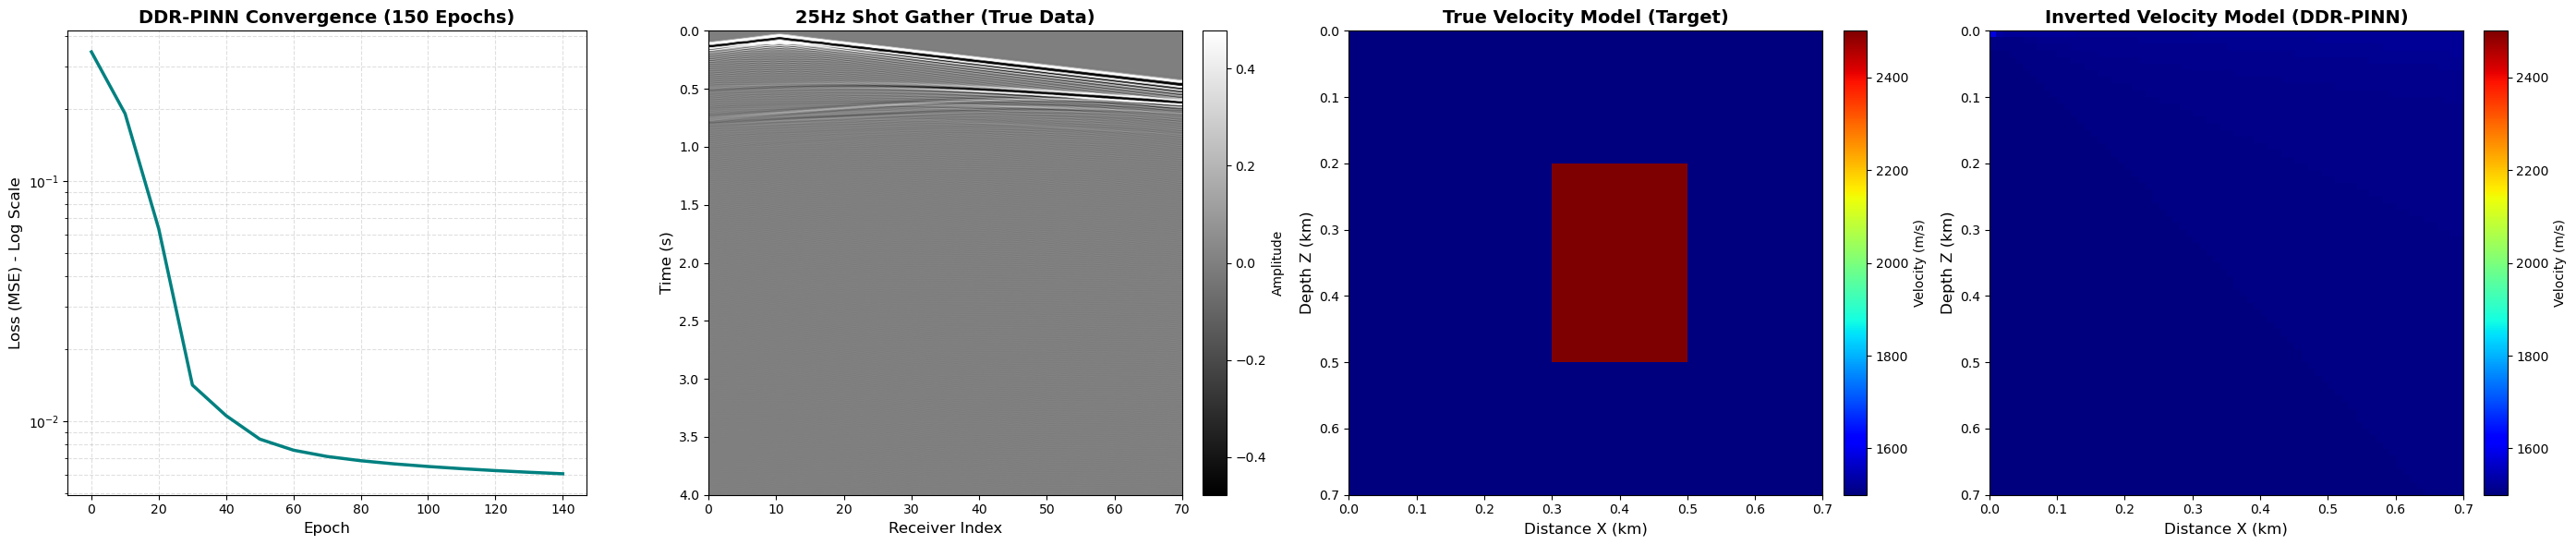

In [5]:
# ==========================================
# CELL 5: DDR-PINN VISUAL ANALYSIS DASHBOARD (4-PANEL)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Extracting tensors and generating visual analysis dashboard...")

# 1. Query the Neural Network and Extract Ground Truth
with torch.no_grad():
    v_pred_flat = v_net(x_flat, z_flat)
    # Reshape the flat predictions back into the 2D spatial grid and transpose
    velocity_model_pred = v_pred_flat.reshape(nx, ny).cpu().numpy().T 
    
    # Extract the True Velocity Model we generated in Cell 1
    velocity_model_true = v_true.cpu().numpy().T

# Extract the first shot gather [receivers, time_samples]
seismogram_data = observed_seismograms[0].cpu().numpy() 

# 2. Establish physical spatial extents (converting meters to kilometers)
x_max = (nx * dx) / 1000.0
z_max = (ny * dx) / 1000.0 

# 3. Initialize the 1x4 Figure Layout
fig, axes = plt.subplots(1, 4, figsize=(28, 6), facecolor='white')

# --- PANEL 1: Convergence Trajectory ---
axes[0].semilogy(history['epoch'], history['loss'], color='teal', linewidth=2.5)
axes[0].set_title('DDR-PINN Convergence (150 Epochs)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE) - Log Scale', fontsize=12)
axes[0].grid(True, which="both", ls="--", alpha=0.4)

# --- PANEL 2: Observed Seismogram (Data) ---
vmax_seismo = np.percentile(np.abs(seismogram_data), 98) 
im_seismo = axes[1].imshow(seismogram_data.T, aspect='auto', cmap='gray', 
                           extent=[0, nx, nt * dt, 0],
                           vmin=-vmax_seismo, vmax=vmax_seismo)
axes[1].set_title('25Hz Shot Gather (True Data)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Receiver Index', fontsize=12)
axes[1].set_ylabel('Time (s)', fontsize=12)
fig.colorbar(im_seismo, ax=axes[1], fraction=0.046, pad=0.04, label='Amplitude')

# --- PANEL 3: True Velocity Model (Ground Truth) ---
im_true = axes[2].imshow(velocity_model_true, aspect='auto', cmap='jet', 
                         extent=[0, x_max, z_max, 0], vmin=1500, vmax=2500)
axes[2].set_title('True Velocity Model (Target)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Distance X (km)', fontsize=12)
axes[2].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im_true, ax=axes[2], fraction=0.046, pad=0.04, label='Velocity (m/s)')

# --- PANEL 4: Inverted Velocity Model (DDR-PINN) ---
# We use the exact same vmin/vmax scale to ensure a 1:1 color comparison
im_pred = axes[3].imshow(velocity_model_pred, aspect='auto', cmap='jet', 
                         extent=[0, x_max, z_max, 0], vmin=1500, vmax=2500)
axes[3].set_title('Inverted Velocity Model (DDR-PINN)', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Distance X (km)', fontsize=12)
axes[3].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im_pred, ax=axes[3], fraction=0.046, pad=0.04, label='Velocity (m/s)')

# 4. Render and Export
plt.tight_layout()
fig.savefig('ddr_pinn_final_dashboard_4panel.png', dpi=300, bbox_inches='tight')
plt.show()